In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("titanic-analise") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://titanic-minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "admin123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

In [2]:
df = spark.read.format("delta") \
    .load("s3a://titanic/lakehouse/gold/titanic")


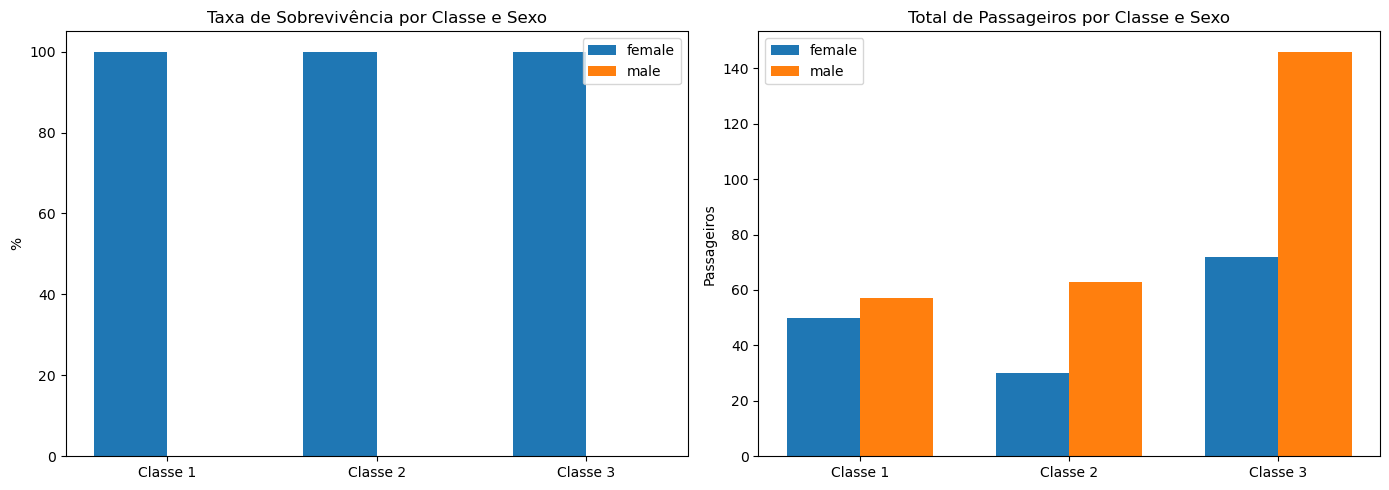

In [3]:
import matplotlib.pyplot as plt
import numpy as np

pdf = df.toPandas()

classes = pdf["Pclass"].unique()
x = np.arange(len(classes))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Taxa de sobrevivência por classe e sexo
for i, sex in enumerate(["female", "male"]):
    dados = pdf[pdf["Sex"] == sex].sort_values("Pclass")
    axes[0].bar(x + i * width, dados["taxa_sobrevivencia_%"], width, label=sex)

axes[0].set_title("Taxa de Sobrevivência por Classe e Sexo")
axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels([f"Classe {c}" for c in classes])
axes[0].set_ylabel("%")
axes[0].legend()

# Gráfico 2 — Total de passageiros por classe
for i, sex in enumerate(["female", "male"]):
    dados = pdf[pdf["Sex"] == sex].sort_values("Pclass")
    axes[1].bar(x + i * width, dados["total"], width, label=sex)

axes[1].set_title("Total de Passageiros por Classe e Sexo")
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels([f"Classe {c}" for c in classes])
axes[1].set_ylabel("Passageiros")
axes[1].legend()

plt.tight_layout()
plt.show()